In [77]:
import pandas as pd
import pyarrow as pa
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List
from typing import Tuple
from typing import Dict

In [78]:
def load_data(
    ranking_path: str = '../nba_dataset/ranking.parquet',
    games_detail_path: str = '../nba_dataset/games_details.parquet',
    games_path: str = '../nba_dataset/games.csv',
    teams_path: str = '../nba_dataset/teams.csv'
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
  
    rnk = pd.read_parquet(ranking_path)
    games_detail = pd.read_parquet(games_detail_path)
    games = pd.read_csv(games_path)
    teams = pd.read_csv(teams_path)
    
    return rnk, games_detail, games, teams

In [79]:
def preprocess_game_dates(games: pd.DataFrame, date_column: str = "GAME_DATE_EST") -> pd.DataFrame:
    """
    게임 날짜를 전처리하고 월(Month) 컬럼 추가
    
    Parameters:
    -----------
    games : pd.DataFrame
        게임 데이터프레임
    date_column : str
        날짜 컬럼명 (기본값: "GAME_DATE_EST")
    
    Returns:
    --------
    pd.DataFrame
        날짜가 전처리되고 Month 컬럼이 추가된 데이터프레임
    """
    games_copy = games.copy()
    games_copy[date_column] = pd.to_datetime(games_copy[date_column])
    games_copy["Month"] = games_copy[date_column].dt.month
    
    return games_copy



In [80]:
def reshape_home_away_to_long(
    games: pd.DataFrame,
    stat_columns: List[str] = ["FG3_PCT", "AST", "REB", "PTS"]
) -> pd.DataFrame:
    """
    홈/어웨이 형식의 게임 데이터를 long format으로 변환
    
    각 게임당 2개의 행(홈팀, 원정팀)으로 변환하여 팀별 분석을 용이하게 합니다.
    
    Parameters:
    -----------
    games : pd.DataFrame
        게임 데이터프레임 (홈/어웨이 분리된 형식)
    stat_columns : List[str]
        변환할 통계 컬럼 리스트
    
    Returns:
    --------
    pd.DataFrame
        Long format으로 변환된 데이터프레임
    """
    # 홈 팀 데이터 추출
    home_cols = ["GAME_DATE_EST", "SEASON", "Month", "TEAM_ID_home"] + \
                [f"{col}_home" for col in stat_columns]
    home = games[home_cols].rename(columns={
        "TEAM_ID_home": "TEAM_ID",
        **{f"{col}_home": col for col in stat_columns}
    })
    
    # 어웨이 팀 데이터 추출
    away_cols = ["GAME_DATE_EST", "SEASON", "Month", "TEAM_ID_away"] + \
                [f"{col}_away" for col in stat_columns]
    away = games[away_cols].rename(columns={
        "TEAM_ID_away": "TEAM_ID",
        **{f"{col}_away": col for col in stat_columns}
    })
    
    # 결합
    long_games = pd.concat([home, away], ignore_index=True)
    
    return long_games


In [81]:
def classify_season_phase(month: int) -> str:
    """
    월(month)을 기반으로 시즌 단계 분류
    
    Parameters:
    -----------
    month : int
        월 (1-12)
    
    Returns:
    --------
    str
        "Early" (10-12월), "Mid" (1-2월), "Late" (3-4월)
    """
    if month in [10, 11, 12]:
        return "Early"
    elif month in [3, 4]:
        return "Late"
    else:
        return "Mid"


In [83]:
def add_season_phase(games: pd.DataFrame, month_column: str = "Month") -> pd.DataFrame:
    """
    시즌 단계(PHASE) 컬럼 추가
    
    Parameters:
    -----------
    games : pd.DataFrame
        게임 데이터프레임
    month_column : str
        월 컬럼명
    
    Returns:
    --------
    pd.DataFrame
        PHASE 컬럼이 추가된 데이터프레임
    """
    games_copy = games.copy()
    games_copy["PHASE"] = games_copy[month_column].apply(classify_season_phase)
    
    return games_copy



In [84]:
def aggregate_by_phase(
    games: pd.DataFrame,
    group_cols: List[str] = ["SEASON", "TEAM_ID", "PHASE"],
    stat_cols: List[str] = ["FG3_PCT", "AST", "REB", "PTS"]
) -> pd.DataFrame:
    """
    시즌 단계별로 팀 통계를 집계 (평균)
    
    Parameters:
    -----------
    games : pd.DataFrame
        게임 데이터프레임
    group_cols : List[str]
        그룹화할 컬럼 리스트
    stat_cols : List[str]
        집계할 통계 컬럼 리스트
    
    Returns:
    --------
    pd.DataFrame
        시즌 단계별로 집계된 데이터프레임
    """
    phase_team = (
        games
        .groupby(group_cols)[stat_cols]
        .mean()
        .reset_index()
    )
    
    return phase_team


In [85]:
def create_phase_comparison_pivot(
    phase_team: pd.DataFrame,
    index_cols: List[str] = ["SEASON", "TEAM_ID"],
    value_cols: List[str] = ["FG3_PCT", "PTS"]
) -> pd.DataFrame:
    """
    시즌 단계별 통계를 피벗하여 초반/후반 비교 가능한 형태로 변환
    
    Parameters:
    -----------
    phase_team : pd.DataFrame
        시즌 단계별로 집계된 데이터프레임
    index_cols : List[str]
        인덱스로 사용할 컬럼 리스트
    value_cols : List[str]
        피벗할 값 컬럼 리스트
    
    Returns:
    --------
    pd.DataFrame
        피벗된 데이터프레임 (Early, Mid, Late 컬럼 포함)
    """
    pivot = (
        phase_team
        .pivot_table(
            index=index_cols,
            columns="PHASE",
            values=value_cols
        )
        .reset_index()
    )
    
    return pivot

In [86]:
def calculate_phase_changes(
    pivot: pd.DataFrame,
    metrics: List[str] = ["FG3_PCT", "PTS"]
) -> pd.DataFrame:
    """
    초반 대비 후반의 통계 변화량 계산
    
    Parameters:
    -----------
    pivot : pd.DataFrame
        피벗된 데이터프레임
    metrics : List[str]
        변화량을 계산할 메트릭 리스트
    
    Returns:
    --------
    pd.DataFrame
        변화량 컬럼이 추가된 데이터프레임
    """
    pivot_copy = pivot.copy()
    
    for metric in metrics:
        change_col = f"{metric.replace('_PCT', '')}_CHANGE"
        pivot_copy[change_col] = pivot_copy[metric]["Late"] - pivot_copy[metric]["Early"]
    
    return pivot_copy

In [87]:
def full_season_analysis_pipeline(
    games_path: str = '../nba_dataset/games.csv',
    stat_columns: List[str] = ["FG3_PCT", "AST", "REB", "PTS"],
    comparison_metrics: List[str] = ["FG3_PCT", "PTS"]
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    전체 시즌 분석 파이프라인 실행
    
    데이터 로드부터 시즌 단계별 비교까지 전체 프로세스를 실행합니다.
    
    Parameters:
    -----------
    games_path : str
        게임 데이터 CSV 파일 경로
    stat_columns : List[str]
        분석할 통계 컬럼 리스트
    comparison_metrics : List[str]
        초반/후반 비교할 메트릭 리스트
    
    Returns:
    --------
    Tuple[pd.DataFrame, pd.DataFrame]
        (long_games, pivot_with_changes) - 변환된 게임 데이터와 피벗 비교 데이터
    """
    # 1. 데이터 로드
    games = pd.read_csv(games_path)
    
    # 2. 날짜 전처리
    games = preprocess_game_dates(games)
    
    # 3. Long format 변환
    long_games = reshape_home_away_to_long(games, stat_columns)
    
    # 4. 시즌 단계 분류
    long_games = add_season_phase(long_games)
    
    # 5. 단계별 집계
    phase_team = aggregate_by_phase(long_games, stat_cols=stat_columns)
    
    # 6. 피벗 테이블 생성
    pivot = create_phase_comparison_pivot(phase_team, value_cols=comparison_metrics)
    
    # 7. 변화량 계산
    pivot_with_changes = calculate_phase_changes(pivot, comparison_metrics)
    
    return long_games, phase_team, pivot_with_changes

In [88]:
def get_cluster_summary(
    df: pd.DataFrame,
    cluster_col: str = "OFFENSE_EVOLUTION_CLUSTER",
    change_cols: List[str] = ["FG3_CHANGE", "AST_CHANGE", "TS_CHANGE"]
) -> pd.DataFrame:
    """
    클러스터별 변화량 요약 통계
    
    Parameters:
    -----------
    df : pd.DataFrame
        클러스터링이 적용된 데이터프레임
    cluster_col : str
        클러스터 컬럼명
    change_cols : List[str]
        요약할 변화량 컬럼 리스트
    
    Returns:
    --------
    pd.DataFrame
        클러스터별 평균 변화량
    """
    return df.groupby(cluster_col)[change_cols].mean()

In [91]:
if __name__ == "__main__":
    long_games, phase_team, pivot = full_season_analysis_pipeline(
        games_path="../nba_dataset/games.csv",
        stat_columns=["FG3_PCT", "AST", "REB", "PTS"],
        comparison_metrics=["FG3_PCT", "PTS"]
    )

    print("\n[LONG FORMAT SAMPLE]")
    print(long_games.head())

    print("\n[PHASE TEAM SAMPLE]")
    print(phase_team.head())

    print("\n[PIVOT WITH CHANGES SAMPLE]")
    print(pivot.head())

    




[LONG FORMAT SAMPLE]
  GAME_DATE_EST  SEASON  Month     TEAM_ID  FG3_PCT   AST   REB    PTS  PHASE
0    2022-12-22    2022     12  1610612740    0.382  25.0  46.0  126.0  Early
1    2022-12-22    2022     12  1610612762    0.457  16.0  40.0  120.0  Early
2    2022-12-21    2022     12  1610612739    0.313  22.0  37.0  114.0  Early
3    2022-12-21    2022     12  1610612755    0.297  27.0  49.0  113.0  Early
4    2022-12-21    2022     12  1610612737    0.378  22.0  47.0  108.0  Early

[PHASE TEAM SAMPLE]
   SEASON     TEAM_ID  PHASE   FG3_PCT        AST        REB         PTS
0    2003  1610612737  Early  0.293941  19.852941  43.764706   89.823529
1    2003  1610612737   Late  0.352913  20.913043  42.130435  101.130435
2    2003  1610612737    Mid  0.329192  19.615385  41.961538   88.884615
3    2003  1610612738  Early  0.349029  21.735294  40.323529   94.617647
4    2003  1610612738   Late  0.319840  19.520000  39.640000   95.680000

[PIVOT WITH CHANGES SAMPLE]
      SEASON     TEAM_

In [93]:
# 멀티인덱스 컬럼 평탄화
pivot.columns = [
    f"{c[0]}_{c[1]}" if isinstance(c, tuple) else c
    for c in pivot.columns
]



In [96]:

pivot.columns




Index(['SEASON_', 'TEAM_ID_', 'FG3_PCT_Early', 'FG3_PCT_Late', 'FG3_PCT_Mid',
       'PTS_Early', 'PTS_Late', 'PTS_Mid', 'FG3_CHANGE_', 'PTS_CHANGE_'],
      dtype='str')

In [97]:
pivot.columns = pivot.columns.str.rstrip("_")


In [98]:
pivot.sort_values("FG3_CHANGE", ascending=False).head(10)


,SEASON,TEAM_ID,FG3_PCT_Early,FG3_PCT_Late,FG3_PCT_Mid,PTS_Early,PTS_Late,PTS_Mid,FG3_CHANGE,PTS_CHANGE
265,2011,1610612763,0.208000,0.341406,0.305579,92.000000,96.687500,92.763158,0.133406,4.687500
246,2011,1610612744,0.262833,0.387676,0.384786,92.333333,97.470588,99.392857,0.124843,5.137255
264,2011,1610612762,0.235167,0.335848,0.292970,90.666667,102.757576,96.030303,0.100682,12.090909
118,2006,1610612766,0.307079,0.399375,0.372357,95.131579,100.791667,96.178571,0.092296,5.660088
239,2011,1610612737,0.276833,0.363312,0.372389,94.166667,100.062500,90.833333,0.086479,5.895833
258,2011,1610612756,0.258000,0.343750,0.354700,92.000000,102.343750,95.333333,0.085750,10.343750
84,2005,1610612762,0.294541,0.380154,0.313923,88.675676,96.692308,92.038462,0.085613,8.016632
79,2005,1610612757,0.282459,0.367846,0.356852,86.837838,88.846154,90.185185,0.085387,2.008316
266,2011,1610612764,0.243600,0.326645,0.296531,84.000000,94.677419,93.656250,0.083045,10.677419
175,2008,1610612763,0.331150,0.412042,0.328115,93.875000,95.333333,91.576923,0.080892,1.458333


In [99]:
pivot.sort_values("PTS_CHANGE").head(10)


,SEASON,TEAM_ID,FG3_PCT_Early,FG3_PCT_Late,FG3_PCT_Mid,PTS_Early,PTS_Late,PTS_Mid,FG3_CHANGE,PTS_CHANGE
491,2019,1610612749,0.362925,0.281333,0.358489,120.000000,105.000000,117.711111,-0.081592,-15.000000
348,2014,1610612756,0.364450,0.289636,0.335962,106.375000,93.181818,104.846154,-0.074814,-13.193182
250,2011,1610612748,0.365833,0.318294,0.365353,106.166667,93.441176,100.843137,-0.047539,-12.725490
525,2020,1610612753,0.331222,0.330103,0.347289,114.555556,102.689655,103.605263,-0.001119,-11.865900
509,2020,1610612737,0.370364,0.381467,0.353684,123.000000,112.133333,111.122807,0.011103,-10.866667
487,2019,1610612745,0.350872,0.306600,0.352021,119.846154,110.000000,114.645833,-0.044272,-9.846154
257,2011,1610612755,0.433333,0.335161,0.342364,102.666667,93.193548,90.750000,-0.098172,-9.473118
426,2017,1610612744,0.395825,0.359769,0.380732,115.375000,106.000000,114.829268,-0.036056,-9.375000
519,2020,1610612747,0.449667,0.354786,0.337739,116.222222,107.428571,107.934783,-0.094881,-8.793651
104,2006,1610612752,0.295846,0.365478,0.364115,100.564103,92.304348,100.038462,0.069632,-8.259755


In [100]:
pivot["OFFENSE_GROWTH_SCORE"] = (
    pivot["FG3_CHANGE"]*100 +
    pivot["PTS_CHANGE"]
)



In [101]:
pivot.sort_values("FG3_CHANGE", ascending=False).head(10)
pivot.sort_values("FG3_CHANGE").head(10)


,SEASON,TEAM_ID,FG3_PCT_Early,FG3_PCT_Late,FG3_PCT_Mid,PTS_Early,PTS_Late,PTS_Mid,FG3_CHANGE,PTS_CHANGE,OFFENSE_GROWTH_SCORE
257,2011,1610612755,0.433333,0.335161,0.342364,102.666667,93.193548,90.750000,-0.098172,-9.473118,-19.290323
260,2011,1610612758,0.408667,0.312688,0.304400,93.333333,103.343750,94.733333,-0.095979,10.010417,0.412500
519,2020,1610612747,0.449667,0.354786,0.337739,116.222222,107.428571,107.934783,-0.094881,-8.793651,-18.281746
240,2011,1610612738,0.432833,0.342030,0.329633,90.333333,93.545455,89.387755,-0.090803,3.212121,-5.868182
491,2019,1610612749,0.362925,0.281333,0.358489,120.000000,105.000000,117.711111,-0.081592,-15.000000,-23.159167
348,2014,1610612756,0.364450,0.289636,0.335962,106.375000,93.181818,104.846154,-0.074814,-13.193182,-20.674545
143,2007,1610612761,0.410400,0.336067,0.416840,96.857143,100.000000,104.400000,-0.074333,3.142857,-4.290476
523,2020,1610612751,0.427545,0.357414,0.398294,120.272727,116.379310,117.647059,-0.070132,-3.893417,-10.906583
64,2005,1610612742,0.402447,0.334931,0.374152,97.736842,96.689655,100.934783,-0.067516,-1.047187,-7.798820
9,2003,1610612746,0.340897,0.273917,0.330333,96.206897,91.458333,95.600000,-0.066980,-4.748563,-11.446552


In [102]:
from sklearn.preprocessing import StandardScaler

def scale_features(
    df: pd.DataFrame,
    feature_cols: List[str]
) -> pd.DataFrame:
    """
    선택한 피처들을 표준화
    """
    scaler = StandardScaler()
    scaled = scaler.fit_transform(df[feature_cols])

    scaled_df = pd.DataFrame(
        scaled,
        columns=[f"{c}_SCALED" for c in feature_cols]
    )

    return scaled_df


In [103]:
from sklearn.cluster import KMeans

def run_kmeans(
    df: pd.DataFrame,
    feature_cols: List[str],
    k: int = 4,
    random_state: int = 42
) -> pd.Series:
    """
    KMeans 클러스터링 수행
    """
    kmeans = KMeans(n_clusters=k, random_state=random_state)
    labels = kmeans.fit_predict(df[feature_cols])
    return pd.Series(labels, name="OFFENSE_EVOLUTION_CLUSTER")


In [104]:
def offense_clustering_pipeline(
    pivot_df: pd.DataFrame,
    feature_cols: List[str] = ["FG3_CHANGE", "PTS_CHANGE"],
    k: int = 4
) -> pd.DataFrame:
    """
    변화량 기반 공격 성향 클러스터링
    """
    df = pivot_df.copy()

    scaled = scale_features(df, feature_cols)
    df = pd.concat([df, scaled], axis=1)

    cluster_labels = run_kmeans(
        df,
        feature_cols=[f"{c}_SCALED" for c in feature_cols],
        k=k
    )

    df["OFFENSE_EVOLUTION_CLUSTER"] = cluster_labels
    return df


In [105]:
def summarize_clusters(
    df: pd.DataFrame,
    cluster_col: str = "OFFENSE_EVOLUTION_CLUSTER",
    change_cols: List[str] = ["FG3_CHANGE", "PTS_CHANGE"]
) -> pd.DataFrame:
    """
    클러스터별 평균 변화량
    """
    return (
        df.groupby(cluster_col)[change_cols]
          .mean()
          .round(3)
          .reset_index()
    )


In [107]:
pivot.isna().sum()


SEASON                   0
TEAM_ID                  0
FG3_PCT_Early            0
FG3_PCT_Late            30
FG3_PCT_Mid             28
PTS_Early                0
PTS_Late                30
PTS_Mid                 28
FG3_CHANGE              30
PTS_CHANGE              30
OFFENSE_GROWTH_SCORE    30
dtype: int64

In [108]:
pivot = pivot.dropna(subset=["FG3_PCT_Early", "FG3_PCT_Late",
                             "PTS_Early", "PTS_Late"])


In [109]:
pivot["FG3_CHANGE"] = pivot["FG3_PCT_Late"] - pivot["FG3_PCT_Early"]
pivot["PTS_CHANGE"] = pivot["PTS_Late"] - pivot["PTS_Early"]


In [110]:
pivot[["FG3_CHANGE","PTS_CHANGE"]].isna().sum()


FG3_CHANGE    0
PTS_CHANGE    0
dtype: int64

In [111]:
pivot.head()

,SEASON,TEAM_ID,FG3_PCT_Early,FG3_PCT_Late,FG3_PCT_Mid,PTS_Early,PTS_Late,PTS_Mid,FG3_CHANGE,PTS_CHANGE,OFFENSE_GROWTH_SCORE
0,2003,1610612737,0.293941,0.352913,0.329192,89.823529,101.130435,88.884615,0.058972,11.306905,17.204092
1,2003,1610612738,0.349029,0.319840,0.334964,94.617647,95.680000,93.892857,-0.029189,1.062353,-1.856588
2,2003,1610612739,0.320206,0.332522,0.312111,91.029412,94.478261,93.851852,0.012316,3.448849,4.680435
3,2003,1610612740,0.340667,0.291500,0.319517,93.363636,89.142857,90.379310,-0.049167,-4.220779,-9.137446
4,2003,1610612741,0.363344,0.336739,0.347071,88.062500,90.434783,89.821429,-0.026605,2.372283,-0.288179


In [112]:
pivot["PTS_CHANGE"] = pivot["PTS_Late"] - pivot["PTS_Early"]


In [113]:
pivot[["FG3_CHANGE","PTS_CHANGE"]].head()


,FG3_CHANGE,PTS_CHANGE
0,0.058972,11.306905
1,-0.029189,1.062353
2,0.012316,3.448849
3,-0.049167,-4.220779
4,-0.026605,2.372283


In [114]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 사용할 변수
features = ["FG3_CHANGE", "PTS_CHANGE"]

# 스케일링
scaler = StandardScaler()
X = scaler.fit_transform(pivot[features])

# KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
pivot["OFFENSE_CLUSTER"] = kmeans.fit_predict(X)


In [115]:
pivot.groupby("OFFENSE_CLUSTER")[features].mean().round(3)


,FG3_CHANGE,PTS_CHANGE
OFFENSE_CLUSTER,,
0,-0.024,-3.247
1,-0.012,3.589
2,0.042,7.537
3,0.028,0.513


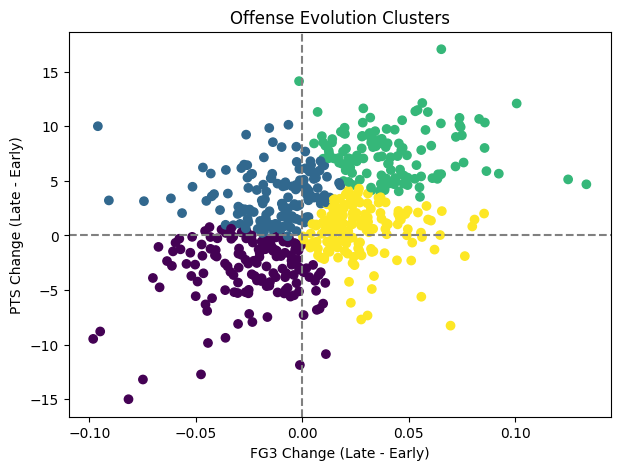

In [116]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(
    pivot["FG3_CHANGE"],
    pivot["PTS_CHANGE"],
    c=pivot["OFFENSE_CLUSTER"]
)
plt.axhline(0, color="gray", linestyle="--")
plt.axvline(0, color="gray", linestyle="--")
plt.xlabel("FG3 Change (Late - Early)")
plt.ylabel("PTS Change (Late - Early)")
plt.title("Offense Evolution Clusters")
plt.show()


In [117]:
pivot.groupby("OFFENSE_CLUSTER")[["FG3_CHANGE","PTS_CHANGE"]].mean().round(3)


,FG3_CHANGE,PTS_CHANGE
OFFENSE_CLUSTER,,
0,-0.024,-3.247
1,-0.012,3.589
2,0.042,7.537
3,0.028,0.513


In [119]:
rnk["STANDINGSDATE"] = pd.to_datetime(rnk["STANDINGSDATE"])

final_rnk = (
    rnk.sort_values("STANDINGSDATE")
       .groupby(["SEASON_ID","TEAM_ID"])
       .tail(1)
)



In [120]:
final_rnk["CONF_RANK"] = (
    final_rnk
    .groupby(["SEASON_ID","CONFERENCE"])["W_PCT"]
    .rank(ascending=False, method="first")
)


In [121]:
final_rnk["PLAYOFFS"] = (final_rnk["CONF_RANK"] <= 8).astype(int)


In [122]:
final_rnk[["SEASON_ID","TEAM_ID","CONFERENCE","W_PCT","CONF_RANK","PLAYOFFS"]].head()


,SEASON_ID,TEAM_ID,CONFERENCE,W_PCT,CONF_RANK,PLAYOFFS
92908,22002,1610612746,West,0.329,13.0,0
92902,22002,1610612762,West,0.573,7.0,1
92901,22002,1610612757,West,0.610,5.0,1
92900,22002,1610612747,West,0.610,6.0,1
92899,22002,1610612750,West,0.622,4.0,1


In [123]:
final_rnk["SEASON"] = final_rnk["SEASON_ID"] % 10000


In [124]:
playoff_df = pivot.merge(
    final_rnk[["SEASON","TEAM_ID","PLAYOFFS"]],
    on=["SEASON","TEAM_ID"],
    how="left"
)


In [125]:
cluster_playoff_rate = (
    playoff_df
    .groupby("OFFENSE_CLUSTER")["PLAYOFFS"]
    .mean()
    .round(3)
)

cluster_playoff_rate


OFFENSE_CLUSTER
0    0.641
1    0.469
2    0.403
3    0.601
Name: PLAYOFFS, dtype: float64

In [126]:
summary = (
    playoff_df
    .groupby("OFFENSE_CLUSTER")[["FG3_CHANGE","PTS_CHANGE","PLAYOFFS"]]
    .mean()
    .round(3)
)

summary


,FG3_CHANGE,PTS_CHANGE,PLAYOFFS
OFFENSE_CLUSTER,,,
0,-0.024,-3.247,0.641
1,-0.012,3.589,0.469
2,0.042,7.537,0.403
3,0.028,0.513,0.601


In [127]:
#----------------
#로지스틱 회귀
#---------------

import numpy as np
import pandas as pd

# final_rnk: 시즌 최종 스탠딩 + PLAYOFFS 만든 테이블 (이전 단계에서 만든 것)
# playoff_df: pivot + PLAYOFFS merge 결과

# W_PCT까지 붙이기
model_df = playoff_df.merge(
    final_rnk[["SEASON", "TEAM_ID", "W_PCT"]],
    on=["SEASON", "TEAM_ID"],
    how="left"
)

# 학습에 쓸 컬럼
feature_cols = ["FG3_CHANGE", "PTS_CHANGE", "W_PCT"]  # W_PCT 빼고 싶으면 여기서 제거
target_col = "PLAYOFFS"

# 결측 제거
model_df = model_df.dropna(subset=feature_cols + [target_col]).copy()

model_df[feature_cols + [target_col]].head()


,FG3_CHANGE,PTS_CHANGE,W_PCT,PLAYOFFS
0,0.058972,11.306905,0.000,1
1,0.058972,11.306905,0.341,1
2,0.058972,11.306905,0.000,0
3,0.058972,11.306905,0.341,0
4,-0.029189,1.062353,0.000,0


In [128]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

X = model_df[feature_cols]
y = model_df[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])

pipe.fit(X_train, y_train)

pred = pipe.predict(X_test)
proba = pipe.predict_proba(X_test)[:, 1]

print("ROC-AUC:", round(roc_auc_score(y_test, proba), 3))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))
print(classification_report(y_test, pred, digits=3))


ROC-AUC: 0.769
Confusion Matrix:
 [[152  60]
 [ 65 179]]
              precision    recall  f1-score   support

           0      0.700     0.717     0.709       212
           1      0.749     0.734     0.741       244

    accuracy                          0.726       456
   macro avg      0.725     0.725     0.725       456
weighted avg      0.726     0.726     0.726       456



In [129]:
model_df["PLAYOFF_PROB"] = pipe.predict_proba(model_df[feature_cols])[:, 1]

# 확률 높은 팀/시즌 Top 15
model_df.sort_values("PLAYOFF_PROB", ascending=False)[
    ["SEASON","TEAM_ID","PLAYOFFS","PLAYOFF_PROB"] + feature_cols
].head(15)


,SEASON,TEAM_ID,PLAYOFFS,PLAYOFF_PROB,FG3_CHANGE,PTS_CHANGE,W_PCT
1030,2011,1610612755,1,0.957105,-0.098172,-9.473118,1.0
1028,2011,1610612755,1,0.957105,-0.098172,-9.473118,1.0
2078,2020,1610612747,1,0.955699,-0.094881,-8.793651,1.0
2076,2020,1610612747,1,0.955699,-0.094881,-8.793651,1.0
994,2011,1610612746,1,0.946570,-0.045429,-6.314286,1.0
992,2011,1610612746,1,0.946570,-0.045429,-6.314286,1.0
2094,2020,1610612751,1,0.944080,-0.070132,-3.893417,1.0
2092,2020,1610612751,1,0.944080,-0.070132,-3.893417,1.0
2174,2021,1610612741,1,0.942885,-0.036202,-5.006486,1.0
2172,2021,1610612741,1,0.942885,-0.036202,-5.006486,1.0


In [130]:
coef = pipe.named_steps["lr"].coef_[0]
coef_df = pd.DataFrame({"feature": feature_cols, "coef": coef}).sort_values("coef", ascending=False)
coef_df


,feature,coef
2,W_PCT,1.044062
0,FG3_CHANGE,-0.066747
1,PTS_CHANGE,-0.183817


In [131]:
def fit_eval_logit(df, features):
    X = df[features]
    y = df["PLAYOFFS"].astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
    ])

    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    return pipe, auc

df2 = model_df.dropna(subset=["FG3_CHANGE","PTS_CHANGE","W_PCT","PLAYOFFS"]).copy()

m1, auc1 = fit_eval_logit(df2, ["FG3_CHANGE","PTS_CHANGE"])
m2, auc2 = fit_eval_logit(df2, ["FG3_CHANGE","PTS_CHANGE","W_PCT"])

print("AUC (change only):", round(auc1, 3))
print("AUC (+ W_PCT):    ", round(auc2, 3))


AUC (change only): 0.612
AUC (+ W_PCT):     0.769


In [134]:
cluster_map = playoff_df[["SEASON","TEAM_ID","OFFENSE_CLUSTER"]].drop_duplicates()
model_df = model_df.merge(cluster_map, on=["SEASON","TEAM_ID"], how="left")

model_df.groupby("OFFENSE_CLUSTER")["PLAYOFF_PROB"].mean().round(3)


OFFENSE_CLUSTER
0    0.598
1    0.472
2    0.389
3    0.541
Name: PLAYOFF_PROB, dtype: float64

In [135]:
cmp = model_df.groupby("OFFENSE_CLUSTER").agg(
    n=("PLAYOFFS", "size"),
    actual_rate=("PLAYOFFS", "mean"),
    pred_prob=("PLAYOFF_PROB", "mean")
).round(3)

cmp


,n,actual_rate,pred_prob
OFFENSE_CLUSTER,,,
0,580,0.641,0.598
1,588,0.469,0.472
2,496,0.403,0.389
3,612,0.601,0.541


In [136]:
pivot.groupby("OFFENSE_CLUSTER")[["FG3_CHANGE","PTS_CHANGE"]].mean().round(3)


,FG3_CHANGE,PTS_CHANGE
OFFENSE_CLUSTER,,
0,-0.024,-3.247
1,-0.012,3.589
2,0.042,7.537
3,0.028,0.513


In [137]:
model_df.groupby("OFFENSE_CLUSTER")["W_PCT"].mean().round(3)


OFFENSE_CLUSTER
0    0.517
1    0.451
2    0.419
3    0.510
Name: W_PCT, dtype: float64

<Axes: >

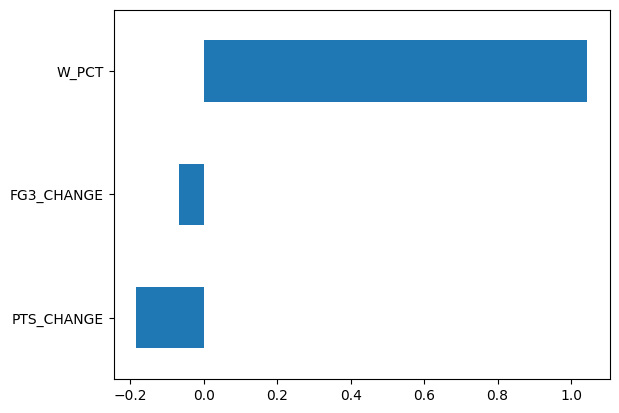

In [138]:
coef = pipe.named_steps["lr"].coef_[0]
pd.Series(coef, index=feature_cols).sort_values().plot(kind="barh")
